In [4]:
from langgraph.graph import StateGraph, START,END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os 
from langchain.chat_models import init_chat_model

In [3]:
load_dotenv()

True

In [5]:
chat_model = os.getenv('CHAT_MODEL')
llm = init_chat_model(model=chat_model)
llm.invoke('Hi')

AIMessage(content='Hi! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 7, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EF6CAf2CG1lDMJSuwtrgZs0g69DoB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02170-e41b-7c13-9053-656957547ad3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 14, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [10]:
def chat_bot(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}

In [22]:
from langchain_core.messages.utils import trim_messages, count_tokens_approximately


def chat_bot_trimming(state: MessagesState):

    before_tokens = count_tokens_approximately(state['messages'])

    trimmed = trim_messages(
        state['messages'],
        strategy="last",
        max_tokens=50,
        token_counter=count_tokens_approximately,
    )

    after_tokens = count_tokens_approximately(trimmed)
    print(f"[tokens] before trim: {before_tokens}, after trim: {after_tokens}")

    response = llm.invoke(trimmed)
    return {"messages": [response]}

In [24]:
graph = StateGraph(MessagesState)

# graph.add_node('chat_bot',chat_bot)
graph.add_node('chat_bot',chat_bot_trimming)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

checkpointer_graph = graph.compile(checkpointer)


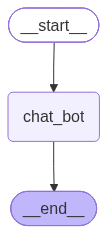

In [25]:
## Display
from IPython.display import Image, display
display(Image(checkpointer_graph.get_graph().draw_mermaid_png()))

In [26]:
print('To end: exit,q,quit')

_user_id = None 

while True:

    if not _user_id : 
        _user_id = input('User id: ')

    _input = input('User: ')
    
    if _input in ('q','quit','exit'):
        _user_id = None
        break

    
    
    message = {
        'messages':[
            {
                'role':'user',
                'content':_input
            }
        ]
    }

    config = {
        'configurable':{
            'thread_id':_user_id
        }
    }

    print('AI: ', end='', flush=True)
    for chunk, metadata in checkpointer_graph.stream(message, config, stream_mode="messages"):
        if chunk.content:
            print(chunk.content, end='', flush=True)
    print()  

To end: exit,q,quit
AI: [tokens] before trim: 1505, after trim: 8
Hi Tej! Nice to meet you—how can I help you today?
AI: [tokens] before trim: 1531, after trim: 34
Sure 😄

Why don’t skeletons fight each other?  
Because they don’t have the **guts**.
AI: [tokens] before trim: 1566, after trim: 43
1. I tried to catch fog yesterday—mist.  
2. My computer told me it needed a break, so I gave it a vacation.  
3. I asked my plants for advice; they said, “Leaf it alone.”  
4. The elevator is never trustworthy—it always lets you down.  
5. I used to hate facial hair, but then it grew on me.  
6. I would tell you a UDP joke, but you might not get it.  
7. Why do programmers prefer dark mode? Because light attracts bugs.  
8. I got my dog a new name—turns out he already had one.  
9. I’m reading a book about anti-gravity… it’s impossible to put down.  
10. My wallet and I broke up; it said it needed space.  
11. I told my phone to stop autocorrecting my words—now it just stares.  
12. Why don’t 

In [27]:
# Due to trimming the context gets lost.